# EARS Geothermal — Factorial Results Analysis

Analyze and visualize solved scenario networks of the main factorial
(`MODELING_PLAN.md` §6): **year (2030/40/50) × hydro (normal/dry) × demand (GEGIS/HEG) × geothermal (geo/nogeo)**.

**How to use:** paste the path(s) of the solved `.nc` file(s) into the `PASTE`
list in the first code cell and run the notebook top-to-bottom. Any path works
(absolute or relative). Factorial coordinates (year/hydro/demand/geo) are
inferred from the filename where possible — they're only needed for the
value-of-geothermal pairing, everything else works regardless.

Files named `<year>_<hydro>_<demand>_<geo>.nc` in `scenarios/` (e.g.
`2050_dry_HEG_geo.nc`) are additionally picked up automatically.

**Two rules to never forget when reading numbers:**
1. **Snapshot weighting** — energy = dispatch × `snapshot_weightings.objective`. Every function here does this; don't sum raw time series.
2. **Resolution caveat** — 168H (weekly) runs erase the diurnal cycle: solar looks firm, storage looks useless (validated 2026-07-12: same cell at 168H vs 4H → battery 0 vs 267 GWh, cost +73%). Only ≥4H runs are thesis-reportable (§3e).

In [2]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# consistent carrier colors across all plots
COLORS = {
    "hydro": "#2166ac", "ror": "#67a9cf", "geothermal": "#b2182b",
    "solar": "#fdb863", "onwind": "#5aae61", "oil": "#4d4d4d",
    "battery": "#9970ab", "H2": "#c2a5cf", "load": "#000000",
    "waste": "#8c510a", "biomass": "#8c510a", "OCGT": "#878787", "PHS": "#51dbcc",
}
CARRIER_ORDER = ["hydro", "ror", "geothermal", "solar", "onwind", "oil", "OCGT", "waste", "load"]

# ════════════════════════════════════════════════════════════════════════════
# PASTE the path(s) of the solved .nc file(s) you want to analyze here.
# Absolute or relative paths both work; raw strings (r"...") save you from
# escaping Windows backslashes. Everything below analyzes whatever is listed.
# ════════════════════════════════════════════════════════════════════════════
PASTE = [
     r"scenarios/tests/B4h_2050_dry_heg_geo.nc",
    # r"C:\Users\user\PycharmProjects\earthkit\pypsa-earth\results\ET_2050\networks\elec_s_6_ec_lcopt_168H.nc",
]

# Factorial cells named <year>_<hydro>_<demand>_<geo>.nc in scenarios/ are ALSO
# picked up automatically (set AUTO_DISCOVER = False to analyze only PASTE).
AUTO_DISCOVER = True
PATTERN = re.compile(r"(?P<year>20[345]0)_(?P<hydro>normal|dry)_(?P<demand>GEGIS|HEG)_(?P<geo>geo|nogeo)\.nc$")

def parse_meta(path):
    """Infer factorial coordinates from the filename where possible."""
    m = PATTERN.search(os.path.basename(path))
    if m:
        return m.groupdict()
    name = os.path.basename(path).lower()
    return dict(
        year=next((y for y in ("2030", "2040", "2050") if y in name), "?"),
        hydro="dry" if "dry" in name else ("normal" if "normal" in name else "?"),
        demand="HEG" if "heg" in name else ("GEGIS" if "gegis" in name else "?"),
        geo="nogeo" if "nogeo" in name or "frozen" in name else ("geo" if "geo" in name else "?"),
    )

RUNS = {}
for p in PASTE:
    if not os.path.isfile(p):
        print(f"  !! not found, skipped: {p}")
        continue
    label = os.path.splitext(os.path.basename(p))[0]
    RUNS[label] = dict(path=p, **parse_meta(p))
if AUTO_DISCOVER:
    for p in sorted(glob.glob(os.path.join("scenarios", "*.nc"))):
        m = PATTERN.search(os.path.basename(p))
        if m:
            d = m.groupdict()
            label = f"{d['year']}·{d['hydro']}·{d['demand']}·{d['geo']}"
            RUNS.setdefault(label, dict(path=p, **d))

print(f"{len(RUNS)} runs registered:")
for k, v in RUNS.items():
    print(f"  {k:40s} {v['path']}")
if not RUNS:
    print("  -> paste at least one .nc path into PASTE above and re-run this cell")

1 runs registered:
  B4h_2050_dry_heg_geo                     scenarios/tests/B4h_2050_dry_heg_geo.nc


## Metric extraction (weighted, cached)

In [3]:
_cache = {}

def load_net(path):
    if path not in _cache:
        _cache[path] = pypsa.Network(path)
    return _cache[path]

def energy_by_carrier(n):
    """Annual generation per carrier in TWh (generators + storage-unit discharge), weighted."""
    w = n.snapshot_weightings.objective
    gen = n.generators_t.p.mul(w, axis=0).sum().groupby(n.generators.carrier).sum()
    sug = n.storage_units_t.p.clip(lower=0).mul(w, axis=0).sum().groupby(n.storage_units.carrier).sum()
    return pd.concat([gen, sug]).groupby(level=0).sum() / 1e6

def metrics(path):
    n = load_net(path)
    w = n.snapshot_weightings.objective
    e = energy_by_carrier(n)
    dem = n.loads_t.p_set.mul(w, axis=0).sum().sum() / 1e6
    geo = n.generators[n.generators.carrier == "geothermal"]
    ext = n.generators[n.generators.p_nom_extendable & ~n.generators.carrier.isin(["load"])]
    built = (ext.p_nom_opt - ext.p_nom).groupby(ext.carrier).sum()
    stores = n.stores.groupby(n.stores.carrier).e_nom_opt.sum() if len(n.stores) else pd.Series(dtype=float)
    geo_gen = e.get("geothermal", 0.0)
    geo_mw = geo.p_nom_opt.sum()
    return dict(
        demand_TWh=dem,
        cost_BEUR=n.objective / 1e9,
        unserved_GWh=e.get("load", 0.0) * 1e3,
        unserved_pct=e.get("load", 0.0) / dem * 100 if dem else np.nan,
        geo_built_MW=geo_mw,
        geo_gen_TWh=geo_gen,
        geo_share_pct=geo_gen / dem * 100 if dem else np.nan,
        geo_flh=geo_gen * 1e6 / geo_mw if geo_mw > 0 else np.nan,
        solar_built_MW=built.get("solar", 0.0),
        wind_built_MW=built.get("onwind", 0.0),
        battery_GWh=stores.get("battery", 0.0) / 1e3,
        H2_GWh=stores.get("H2", 0.0) / 1e3,
        hydro_gen_TWh=e.get("hydro", 0.0) + e.get("ror", 0.0),
    )

summary = pd.DataFrame({label: metrics(v["path"]) for label, v in RUNS.items()}).T
meta = pd.DataFrame({label: {k: v[k] for k in ("year", "hydro", "demand", "geo")} for label, v in RUNS.items()}).T
summary = meta.join(summary)
summary

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, lines, links, loads, storage_units, stores


,year,hydro,demand,geo,demand_TWh,cost_BEUR,unserved_GWh,unserved_pct,geo_built_MW,geo_gen_TWh,geo_share_pct,geo_flh,solar_built_MW,wind_built_MW,battery_GWh,H2_GWh,hydro_gen_TWh
B4h_2050_dry_heg_geo,2050,dry,HEG,geo,289.00,13.06,0.00,0.00,"4,089.30",32.25,11.16,"7,885.56","145,031.51","16,776.80",267.43,0.00,17.42


## Generation mix per scenario (stacked)

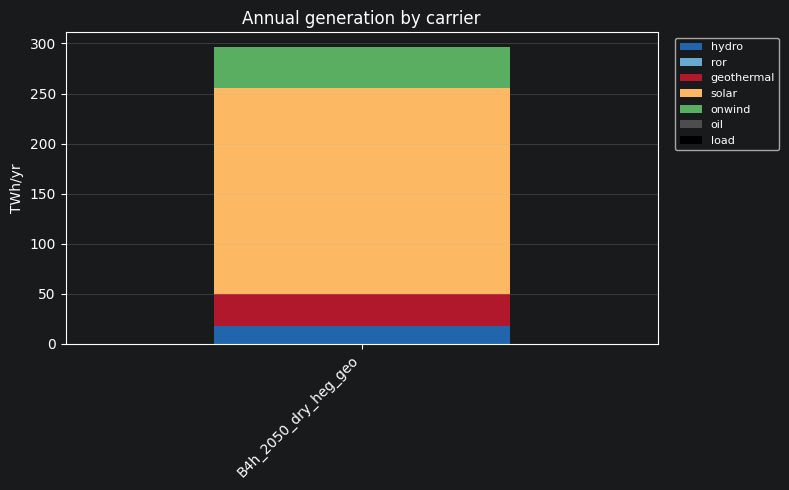

In [4]:
mix = pd.DataFrame({label: energy_by_carrier(load_net(v["path"])) for label, v in RUNS.items()}).T.fillna(0)
cols = [c for c in CARRIER_ORDER if c in mix.columns] + [c for c in mix.columns if c not in CARRIER_ORDER]
mix = mix[cols]

ax = mix.plot(kind="bar", stacked=True, figsize=(max(8, len(mix) * 0.9), 5),
              color=[COLORS.get(c, "#cccccc") for c in mix.columns])
ax.set_ylabel("TWh/yr")
ax.set_title("Annual generation by carrier")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## New capacity built per scenario

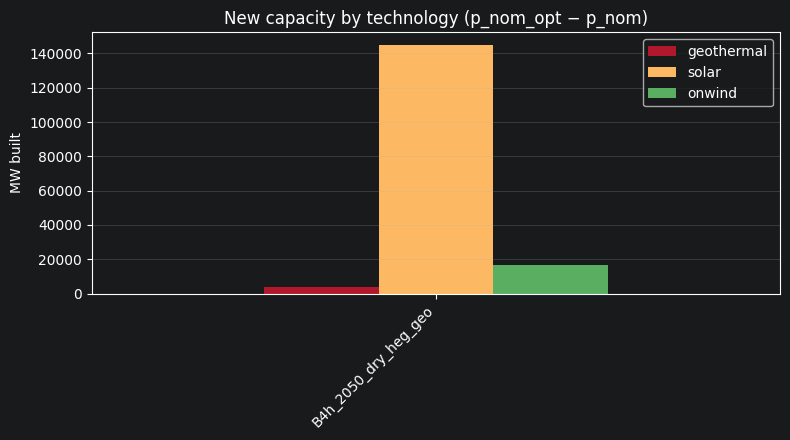

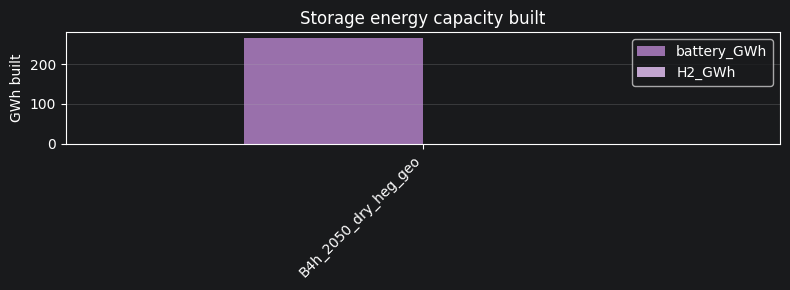

In [5]:
cap = summary[["geo_built_MW", "solar_built_MW", "wind_built_MW"]].astype(float)
cap.columns = ["geothermal", "solar", "onwind"]
ax = cap.plot(kind="bar", figsize=(max(8, len(cap) * 0.9), 4.5),
              color=[COLORS[c] for c in cap.columns])
ax.set_ylabel("MW built")
ax.set_title("New capacity by technology (p_nom_opt − p_nom)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# storage on its own axis (GWh, different unit)
st = summary[["battery_GWh", "H2_GWh"]].astype(float)
if st.values.sum() > 0.1:
    ax2 = st.plot(kind="bar", figsize=(max(8, len(st) * 0.9), 3),
                  color=[COLORS["battery"], COLORS["H2"]])
    ax2.set_ylabel("GWh built")
    ax2.set_title("Storage energy capacity built")
    ax2.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

## Value of geothermal — the §8 delta
`Value(geo | cell) = X(nogeo) − X(geo)` for each dry cell that has both twins.

In [ ]:
pairs = []
for label, v in RUNS.items():
    if v["geo"] != "geo":
        continue
    # find the nogeo twin by matching factorial coordinates (works for pasted
    # files with arbitrary names, as long as year/hydro/demand were inferred)
    twin = next((t for t, u in RUNS.items()
                 if u["geo"] == "nogeo"
                 and u["year"] == v["year"] and u["hydro"] == v["hydro"]
                 and u["demand"] == v["demand"] and "?" not in (v["year"], v["hydro"], v["demand"])),
                None)
    if twin is None:
        continue
    a, b = summary.loc[label], summary.loc[twin]
    pairs.append({
        "cell": f"{v['year']}·{v['hydro']}·{v['demand']}",
        "Δcost_BEUR": b.cost_BEUR - a.cost_BEUR,
        "Δunserved_GWh": b.unserved_GWh - a.unserved_GWh,
        "Δsolar_MW": b.solar_built_MW - a.solar_built_MW,
        "Δwind_MW": b.wind_built_MW - a.wind_built_MW,
        "Δbattery_GWh": b.battery_GWh - a.battery_GWh,
        "geo_built_MW": a.geo_built_MW,
        "geo_gen_TWh": a.geo_gen_TWh,
    })
value = pd.DataFrame(pairs).set_index("cell") if pairs else pd.DataFrame()
if len(value):
    display(value)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    value["Δcost_BEUR"].plot(kind="bar", ax=axes[0], color="#b2182b")
    axes[0].set_title("Δ system cost (nogeo − geo)"); axes[0].set_ylabel("B€/yr"); axes[0].grid(axis="y", alpha=0.3)
    value["Δunserved_GWh"].plot(kind="bar", ax=axes[1], color="#4d4d4d")
    axes[1].set_title("Δ unserved energy (nogeo − geo)"); axes[1].set_ylabel("GWh/yr"); axes[1].grid(axis="y", alpha=0.3)
    for ax in axes: ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
else:
    print("No geo/nogeo twin pairs found — needs a geo run AND its nogeo twin "
          "with matching year/hydro/demand (inferred from filenames).")

## Geothermal build-out per site

In [ ]:
RUN = list(RUNS)[-1]   # ← pick the run to inspect
n = load_net(RUNS[RUN]["path"])
geo = n.generators[n.generators.carrier == "geothermal"].copy()
geo["site"] = geo.index.str.replace("geothermal ", "", regex=False)
site = geo.set_index("site")[["p_nom_opt", "p_nom_max"]].sort_values("p_nom_max", ascending=True)
ax = site.plot(kind="barh", figsize=(7, max(4, 0.32 * len(site))), color=["#b2182b", "#f4a582"])
ax.set_xlabel("MW")
ax.set_title(f"Geothermal build vs cap — {RUN}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

## Dispatch time series (pick a run and a window)

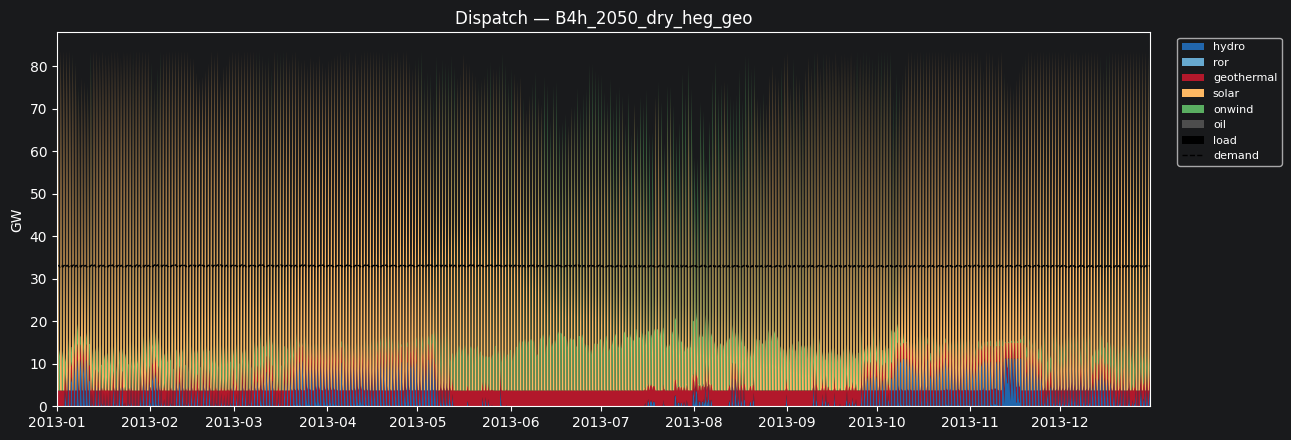

In [6]:
RUN = list(RUNS)[-1]         # ← run to plot
WINDOW = slice(None)          # full year; or e.g. slice("2013-02-01", "2013-03-15") for the dry season

n = load_net(RUNS[RUN]["path"])
gen = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
sto = n.storage_units_t.p.clip(lower=0).T.groupby(n.storage_units.carrier).sum().T
disp = pd.concat([gen, sto], axis=1)
disp = disp.T.groupby(level=0).sum().T.loc[WINDOW] / 1e3   # GW
cols = [c for c in CARRIER_ORDER if c in disp.columns] + [c for c in disp.columns if c not in CARRIER_ORDER]
disp = disp[cols].clip(lower=0)
load = n.loads_t.p_set.sum(axis=1).loc[WINDOW] / 1e3

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.stackplot(disp.index, disp.T.values, labels=disp.columns,
             colors=[COLORS.get(c, "#cccccc") for c in disp.columns])
ax.plot(load.index, load.values, "k--", lw=1, label="demand")
ax.set_ylabel("GW"); ax.set_title(f"Dispatch — {RUN}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.margins(x=0)
plt.tight_layout()

## Seasonal profile — monthly energy by carrier (the dry-season story)

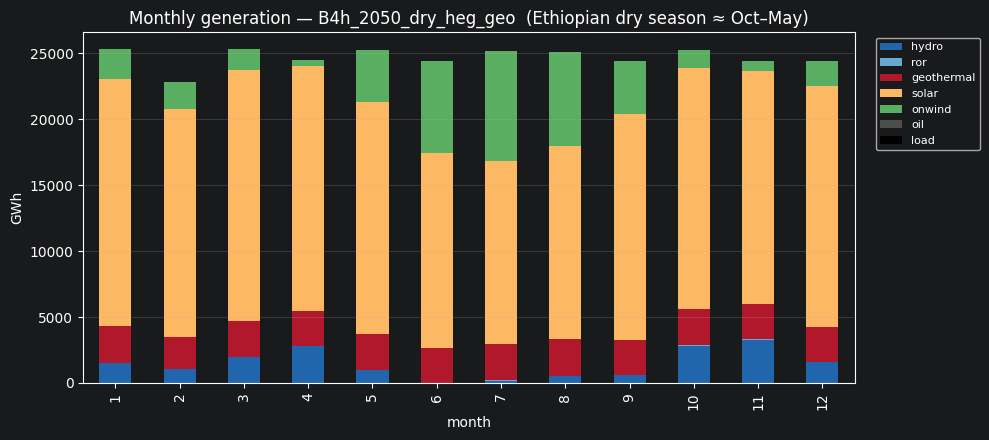

In [7]:
RUN = list(RUNS)[-1]         # ← run to plot
n = load_net(RUNS[RUN]["path"])
w = n.snapshot_weightings.objective
gen = n.generators_t.p.mul(w, axis=0).T.groupby(n.generators.carrier).sum().T
sto = n.storage_units_t.p.clip(lower=0).mul(w, axis=0).T.groupby(n.storage_units.carrier).sum().T
monthly = pd.concat([gen, sto], axis=1)
monthly = monthly.T.groupby(level=0).sum().T
monthly = monthly.groupby(monthly.index.month).sum() / 1e3   # GWh
cols = [c for c in CARRIER_ORDER if c in monthly.columns] + [c for c in monthly.columns if c not in CARRIER_ORDER]
ax = monthly[cols].plot(kind="bar", stacked=True, figsize=(10, 4.5),
                        color=[COLORS.get(c, "#cccccc") for c in cols])
ax.set_xlabel("month"); ax.set_ylabel("GWh")
ax.set_title(f"Monthly generation — {RUN}  (Ethiopian dry season ≈ Oct–May)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## Network map — paper style (Parzen et al. 2023, Fig. 11)

Capacity pies per node; **light grey lines = existing transmission**, **dark rose = newly optimized** capacity (both width-scaled). Set `RUN`, tweak `PIE_SCALE` if pies crowd the map (large-demand scenarios need smaller values).

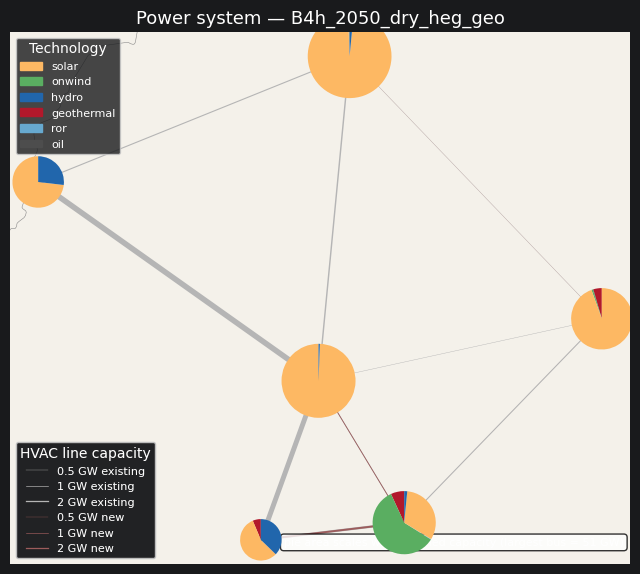

In [9]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

RUN = list(RUNS)[-1]     # ← run to map
PIE_SCALE = 0.20         # biggest pie in deg-area; lower it if pies crowd the map
SAVE = None              # e.g. "plots/2050_dry_HEG_geo_map.png"

n = load_net(RUNS[RUN]["path"])

# capacity pies per (bus, carrier): generators + storage units, minus the backstop
parts = [n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()]
if len(n.storage_units):
    parts.append(n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum())
cap = pd.concat(parts)
cap = cap[cap > 1.0]
cap = cap[~cap.index.get_level_values("carrier").str.contains("load", case=False)]

carriers = list(cap.index.get_level_values("carrier").unique())
cmap = {c: COLORS.get(c, "#999999") for c in carriers}

bus_scale = PIE_SCALE / cap.groupby(level=0).sum().max()
LINE_SCALE = 4.0 / max(n.lines.s_nom_opt.max(), 1.0)     # widest line ~4 pt
exist_w = n.lines.s_nom * LINE_SCALE
new_w = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * LINE_SCALE

acb = n.buses[n.buses.carrier == "AC"]
fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor="#f4f1ea", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dbeaf2", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#888", zorder=1)
ax.coastlines(linewidth=0.4)
ax.set_extent([acb.x.min() - 2.0, acb.x.max() + 2.0,
               acb.y.min() - 2.0, acb.y.max() + 2.0], crs=ccrs.PlateCarree())

def net_plot(**kw):
    """n.plot() across PyPSA versions: 0.30 uses color_geomap, newer uses geomap_color."""
    try:
        n.plot(ax=ax, geomap=True, color_geomap=False, **kw)
    except TypeError:
        n.plot(ax=ax, geomap=True, geomap_color=False, **kw)

# pass 1: existing lines (light grey) + capacity pies
net_plot(bus_sizes=cap * bus_scale, bus_colors=cmap,
         line_widths=exist_w, line_colors="#b5b5b5", link_widths=0.0)
# pass 2: overlay newly optimized line capacity (dark rose), no buses
net_plot(bus_sizes=0, line_widths=new_w, line_colors="#9c5c5c", link_widths=0.0)

tech_handles = [mpatches.Patch(color=cmap[c], label=c)
                for c in sorted(carriers, key=lambda c: -cap.xs(c, level=1).sum())]
leg1 = ax.legend(handles=tech_handles, loc="upper left", fontsize=8,
                 frameon=True, title="Technology")
ax.add_artist(leg1)

gw = 1e3
line_handles = [Line2D([0], [0], color="#b5b5b5", lw=v * gw * LINE_SCALE,
                       label=f"{v:g} GW existing") for v in (0.5, 1, 2)]
line_handles += [Line2D([0], [0], color="#9c5c5c", lw=v * gw * LINE_SCALE,
                        label=f"{v:g} GW new") for v in (0.5, 1, 2)]
leg2 = ax.legend(handles=line_handles, loc="lower left", fontsize=8,
                 frameon=True, title="HVAC line capacity")
ax.add_artist(leg2)

ax.annotate("pie area scales with installed capacity (largest bus = "
            f"{cap.groupby(level=0).sum().max()/1e3:,.0f} GW)",
            xy=(0.99, 0.035), xycoords="axes fraction", ha="right", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))

ax.set_title(f"Power system — {RUN}", fontsize=13)
if SAVE:
    fig.savefig(SAVE, dpi=200, bbox_inches="tight")
    print("saved", SAVE)

## Notes
- **Export figures** for the thesis with `plt.savefig("plots/<name>.png", dpi=200)` after any plot cell.
- **Maps**: `python plot_country_map.py <solved.nc> plots/<name>.png "<title>"` (capacity pies per node, PyPSA-Earth atlas style).
- The `_cache` keeps networks in memory — restart the kernel if RAM gets tight after loading many runs.
- Remember: 168H runs are mechanics tests, not results (§3e). Check `len(n.snapshots)` if unsure: 52 = weekly, 2190 = 4H, 8760 = hourly.